# Step 1: Dataset Overview. #

In [1]:
import os, sys, glob #-- Import libraries. --#
dir = '../Datasets/Train/Engtext'
if not os.path.exists(dir):
    #-- If dir does not exists. --#
    print(f"The {dir} does not exist! Please check the directory again...")
    #-- If dir exists. --#
else:
    print(f"The {dir} exists....")
    #-- List all files in the dir. --#
    csv_files = glob.glob(os.path.join(dir, "*.csv"))
    print("-" * 56)
    #-- Print files in dir. --#
    for file in csv_files:
                print(f"Found files: {file}")
    print("-" * 56)    

The ../Datasets/Train/Engtext exists....
--------------------------------------------------------
Found files: ../Datasets/Train/Engtext\Datasets_01.csv
Found files: ../Datasets/Train/Engtext\Datasets_02.csv
Found files: ../Datasets/Train/Engtext\Datasets_03.csv
Found files: ../Datasets/Train/Engtext\Datasets_04.csv
Found files: ../Datasets/Train/Engtext\Datasets_05.csv
Found files: ../Datasets/Train/Engtext\Datasets_06.csv
Found files: ../Datasets/Train/Engtext\Datasets_07.csv
Found files: ../Datasets/Train/Engtext\Datasets_08.csv
Found files: ../Datasets/Train/Engtext\Datasets_09.csv
Found files: ../Datasets/Train/Engtext\Datasets_10.csv
Found files: ../Datasets/Train/Engtext\Datasets_11.csv
Found files: ../Datasets/Train/Engtext\Datasets_12.csv
Found files: ../Datasets/Train/Engtext\Datasets_13.csv
Found files: ../Datasets/Train/Engtext\Datasets_14.csv
Found files: ../Datasets/Train/Engtext\Datasets_15.csv
--------------------------------------------------------


In [2]:
import pandas as pd #-- Import library. --#
#-- Load and combine all .csv files into one. --#
combined_df = []
for file in csv_files:
    df = pd.read_csv(file)
    combined_df.append(df)
combined_df = pd.concat(combined_df, ignore_index=True)
#-- Take the label column. --#
label_column = combined_df.columns[0] 
#-- Count classes and get class lists --#
total_images = len(combined_df)
total_classes = combined_df[label_column].nunique()
class_list_numbers = sorted(combined_df[label_column].unique())
class_list_letters = [chr(int(x) + 65) for x in class_list_numbers]
#-- Print total image and class details. --#
print(f"Total images in dataset: {total_images}")
print(f"Total classes in dataset: {total_classes}")
print(f"Class list: {class_list_letters}")

Total images in dataset: 297960
Total classes in dataset: 26
Class list: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
#-- Print ALL letters/numbers --#
counts = combined_df[label_column].value_counts().sort_index()
print("Details per letter:")

for number, count in counts.items():
    letter = chr(int(number) + 65)
    print(f"Letter {letter}: {count} images")

Details per letter:
Letter A: 11019 images
Letter B: 6928 images
Letter C: 18704 images
Letter D: 8080 images
Letter E: 9143 images
Letter F: 922 images
Letter G: 4632 images
Letter H: 5769 images
Letter I: 907 images
Letter J: 6791 images
Letter K: 4461 images
Letter L: 9294 images
Letter M: 9849 images
Letter N: 15156 images
Letter O: 46276 images
Letter P: 15424 images
Letter Q: 4638 images
Letter R: 9313 images
Letter S: 38655 images
Letter T: 18057 images
Letter U: 23261 images
Letter V: 3332 images
Letter W: 8711 images
Letter X: 5076 images
Letter Y: 8698 images
Letter Z: 4864 images


# Step 2: Data Distribution Analysis. #


Saved figure to: ../Figures/Text_Class_Distribution.png


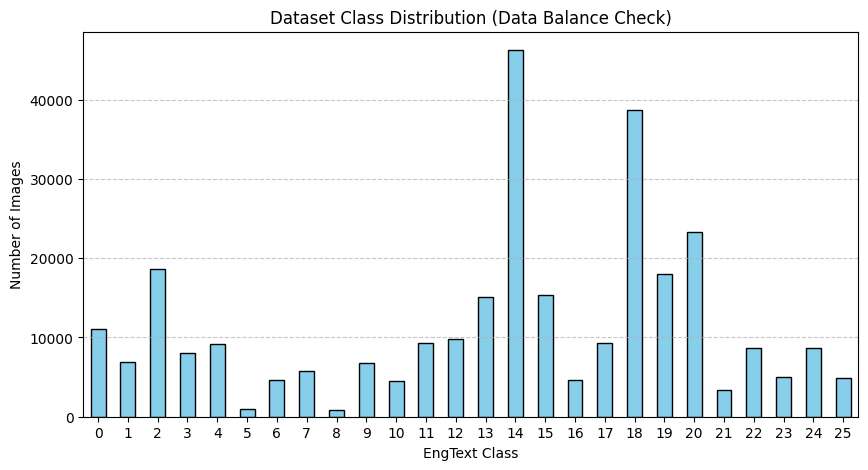

In [5]:
import matplotlib.pyplot as plt
saved_dir = '../Figures/'
plt.figure(figsize=(10, 5))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Dataset Class Distribution (Data Balance Check)')
plt.xlabel('EngText Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
output_path = os.path.join(saved_dir, 'Text_Class_Distribution.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight') # dpi=300 giúp ảnh nét, bbox_inches tránh bị cắt lẹm viền
print(f"\nSaved figure to: {output_path}")
plt.show()

# Step 3: Check Data Quality. #

In [6]:
import cv2
import numpy as np
#-- Collect first smaple data from combined_df. --#
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
image_size = int(np.sqrt(len(pixel_values)))
#-- Conver pixel into 2D. --#
img_2d = pixel_values.reshape((image_size, image_size)).astype(np.uint8)
#-- Calculate Laplace Variance. --#
laplacian_var = cv2.Laplacian(img_2d, cv2.CV_64F).var()
print(f"Laplacian Variance score: {laplacian_var:.2f}")
#-- Check image is blurry or not. --#
threshold = 100.0
if laplacian_var < threshold:
    print("Image seems blurry")
else:
    print("Image is clear, not blurry")


Laplacian Variance score: 13541.29
Image is clear, not blurry


In [7]:
#-- Get the 2D image from the first sample. --#
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
image_size = int(np.sqrt(len(pixel_values)))
img_2d = pixel_values.reshape((image_size, image_size))
#-- Extract the top, bottom, left, and right outer edges. --#
top_edge = img_2d[0, :]
bottom_edge = img_2d[-1, :]
left_edge = img_2d[:, 0]
right_edge = img_2d[:, -1]
#-- Check if any pixels on the edges differ significantly from the background color. --#
background_color = img_2d[0, 0] #-- Sample the background color from the corner. --#
threshold_diff = 50
is_cropped = False
if (abs(top_edge - background_color) > threshold_diff).any() or \
   (abs(bottom_edge - background_color) > threshold_diff).any() or \
   (abs(left_edge - background_color) > threshold_diff).any() or \
   (abs(right_edge - background_color) > threshold_diff).any():
    is_cropped = True
#-- onclusion. --#
if is_cropped:
    print("The image SEEMS to be cropped/cut off (touches or overflows the border).")
else:
    print("The image is NOT cropped; the digit is fully contained within the frame.")

The image is NOT cropped; the digit is fully contained within the frame.


In [8]:
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
image_size = int(np.sqrt(len(pixel_values)))
img_2d = pixel_values.reshape((image_size, image_size)).astype(float)

corner_pixels = np.concatenate([
    img_2d[:3, :3].flatten(),
    img_2d[:3, -3:].flatten(),
    img_2d[-3:, :3].flatten(),
    img_2d[-3:, -3:].flatten()
])

background_std = np.std(corner_pixels)
print(f"Background Standard Deviation (Noise score): {background_std:.2f}")

noise_threshold = 10.0
if background_std > noise_threshold:
    print("The image SEEMS to be noisy.")
else:
    print("The image is clean, no significant noise detected.")

Background Standard Deviation (Noise score): 0.00
The image is clean, no significant noise detected.
